Author: Krish

In [1]:
# Importing relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

### User input required
Put the data path on your system in the cell below

In [2]:
data_path = "CAR_-_EP_Flow_Activity_Queue__Agent_Names"

### User input ends

### Reading all filenames in the data folder

In [3]:
folder = Path(data_path)
files = sorted(list(folder.glob("*.csv")) + list(folder.glob("*.xlsx")))
df_main = pd.DataFrame(columns=['Contact Session ID', 'EP Name', 'Flow Name', 'Activity Name', 'Activity Start Timestamp', 
                                'Queue Name', 'Agent Name', 'Termination Reason'])
df_main

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason


### Reading all data files
The code chunk below reads and appends all the CAR data files. The first two rows of each file are blank and thus ignored.

In [4]:
i=0
for f in files:
    i = i + 1
    if f.suffix.lower() == ".csv":
        df = pd.read_csv(f, header=2, dtype=str, engine="python", skip_blank_lines=False)
    else:  # .xlsx
        df = pd.read_excel(f, sheet_name=0, header=2, dtype=str)
    df_main = pd.concat([df_main, df], ignore_index=True)
    print(i, f.stem, df.shape)

1 CAR - EP, Flow, Activity, Queue, & Agent Names (01-12-25 - 01-18-25) (52010, 7)
2 CAR - EP, Flow, Activity, Queue, & Agent Names (01-19-25 - 02-01-25) (95495, 7)
3 CAR - EP, Flow, Activity, Queue, & Agent Names (02-02-25 - 02-15-25) (90056, 7)
4 CAR - EP, Flow, Activity, Queue, & Agent Names (02-16-25 - 03-01-25) (88186, 7)
5 CAR - EP, Flow, Activity, Queue, & Agent Names (03-02-25 - 03-15-25) (86377, 7)
6 CAR - EP, Flow, Activity, Queue, & Agent Names (04-07-24 - 04-20-24) (88766, 7)
7 CAR - EP, Flow, Activity, Queue, & Agent Names (04-21-24 - 05-04-24) (89643, 7)
8 CAR - EP, Flow, Activity, Queue, & Agent Names (05-05-24 - 05-18-24) (82575, 7)
9 CAR - EP, Flow, Activity, Queue, & Agent Names (05-19-24 - 06-01-24) (71103, 7)
10 CAR - EP, Flow, Activity, Queue, & Agent Names (06-02-24 - 06-15-24) (84354, 7)
11 CAR - EP, Flow, Activity, Queue, & Agent Names (06-16-24 - 06-29-24) (82124, 7)
12 CAR - EP, Flow, Activity, Queue, & Agent Names (06-30-24 - 07-13-24) (79752, 7)
13 CAR - EP, 

### Time datatype conversion
The code chunk below converts time from string to datetime datatype.

In [5]:
df_main["Activity Start Timestamp"] = df_main["Activity Start Timestamp"].apply(
    lambda x: datetime.strptime(x, "%Y/%m/%d %I:%M:%S %p"))

In [6]:
# Checking the datatype of all columns
df_main.dtypes

Contact Session ID                  object
EP Name                             object
Flow Name                           object
Activity Name                       object
Activity Start Timestamp    datetime64[ns]
Queue Name                          object
Agent Name                          object
Termination Reason                  object
dtype: object

In [7]:
# Creating a new column 'hour' as it will be useful to visualize peak calling hours
df_main["hour"] = df_main["Activity Start Timestamp"].dt.hour

### Cleaning Data

In [8]:
# --- 1) FILTER ROWS ---------------------------------------------------------

# Define the three conditions

# Rows that represent a particular menu
cond1 = (
    df_main['EP Name'].notna() &
    df_main['Flow Name'].isna() &
    df_main['Activity Name'].isna()
)

# Rows that represent the beginning / end of a call journey
cond2 = (
    df_main['EP Name'].notna() &
    df_main['Activity Name'].notna() &
    df_main['Flow Name'].isna()
)

# rows that represent presence within a queue
cond3 = df_main['Queue Name'].notna()

# Keep rows that satisfy ANY of the three conditions
df_filt = df_main[cond1 | cond2 | cond3].copy()

# --- 2) TIME DELTA (seconds since previous row within each Contact Session ID) ---

# Ensure timestamp is datetime (safe if it's already datetime64[ns])
df_filt['Activity Start Timestamp'] = pd.to_datetime(df_filt['Activity Start Timestamp'], errors='coerce')

# Sort so "previous row" is truly the prior event in time for that session
# df_filt = df_filt.sort_values(['Contact Session ID', 'Activity Start Timestamp'])

# Compute per-session time difference (first row per session will be NaN)
df_filt['seconds_since_prev'] = (
    df_filt.groupby('Contact Session ID')['Activity Start Timestamp']
           .diff()
           .dt.total_seconds()
)

# b) seconds until next row (last row per session -> NaN)
df_filt['seconds_until_next'] = (
    df_filt.groupby('Contact Session ID')['Activity Start Timestamp']
           .shift(-1)
           .sub(df_filt['Activity Start Timestamp'])
           .dt.total_seconds()
)

# df_filt now has the filtered rows plus the new 'seconds_since_prev' column

### Filtering 1: Filter out intake outdial calls

In [9]:
# Find all Contact Session IDs that contain "Intake Outdial EP"
outdial_sessions = df_filt.loc[df_filt["EP Name"] == "Intake Outdial EP", "Contact Session ID"].unique()

# Exclude those sessions from df_filt
df_outbound = df_filt[~df_filt["Contact Session ID"].isin(outdial_sessions)].copy()

### Filtering 2: Filter for calls that reached MainMenu

In [10]:
df_reached_main = df_outbound[df_outbound["Contact Session ID"].isin(
    df_outbound.loc[df_outbound["Activity Name"] == "MainMenu", "Contact Session ID"].unique()
)].copy()

num_reached_main = df_reached_main["Contact Session ID"].nunique() / df_outbound["Contact Session ID"].nunique()
print(num_reached_main)

0.6930854601814705


### Filtering 3: Filter for calls that reached beyond the MainMenu

In [11]:
qualifying_sessions = []

for contact_id, group in df_reached_main.groupby("Contact Session ID"):
    # Find the first occurrence of MainMenu
    mainmenu_rows = group[group["Activity Name"] == "MainMenu"]
    if mainmenu_rows.empty:
        continue
    
    first_mainmenu_time = mainmenu_rows["Activity Start Timestamp"].iloc[0]
    
    # Rows that occur *after* the first MainMenu
    after_mainmenu = group[group["Activity Start Timestamp"] > first_mainmenu_time]
    
    # Check if there is at least one non-empty Activity Name that isn't MainMenu
    if after_mainmenu["Activity Name"].dropna().ne("MainMenu").any():
        qualifying_sessions.append(contact_id)

# Filter df_reached_main to only those sessions
df_reached_beyond_main = df_reached_main[df_reached_main["Contact Session ID"].isin(qualifying_sessions)].copy()

In [12]:
num_qual = df_reached_beyond_main["Contact Session ID"].nunique() / df_reached_main["Contact Session ID"].nunique()
print(num_qual)

0.9302812650893288


### Filtering 4: Check if caller returns to MainMenu

In [13]:
df_return_sessions = []

# Loop through each session
for contact_id, group in df_reached_beyond_main.groupby("Contact Session ID"):
    # Get activity names in order (dropping NaN)
    activities = group["Activity Name"].dropna().tolist()

    # Find indexes of all MainMenu occurrences
    mainmenu_indices = [i for i, a in enumerate(activities) if a == "MainMenu"]

    # Check if there are non-consecutive MainMenu entries
    if len(mainmenu_indices) > 1:
        non_consecutive = any(mainmenu_indices[i+1] - mainmenu_indices[i] != 1 
                              for i in range(len(mainmenu_indices) - 1))
        if non_consecutive:
            df_return_sessions.append(contact_id)

# Create DataFrames
df_return = df_reached_beyond_main[df_reached_beyond_main["Contact Session ID"].isin(df_return_sessions)].copy()
df_no_return = df_reached_beyond_main[~df_reached_beyond_main["Contact Session ID"].isin(df_return_sessions)].copy()


In [14]:
num_no_return = df_no_return["Contact Session ID"].nunique() / df_reached_beyond_main["Contact Session ID"].nunique()
num_return = df_return["Contact Session ID"].nunique() / df_reached_beyond_main["Contact Session ID"].nunique()
print(num_no_return)
print(num_return)

0.9499185747004133
0.05008142529958671


### Filtering 5: Check if caller reached a queue

In [15]:
# Helper function to get success vs abandoned sessions
def split_success_abandoned(df):
    # Find session IDs with success
    success_sessions = df.loc[
    (
        (df["Activity Name"].isin([
            "ClosedQueueMenu",
            "ChildSupportMenu",
            "SimpleDivorceMenu",
            "TenantDeterrenceMenu",
            "ImmigrationOther",
            "WorkersCompMenu",
            "OtherLegalCriminalCase",
            "OtherLegalPersonalInjury",
            "OtherLegalOther"
        ]))
        | (df["Queue Name"].notna())
    ),
    "Contact Session ID"
].unique()
    
    # Successful calls
    df_success = df[df["Contact Session ID"].isin(success_sessions)].copy()
    
    # Abandoned calls
    df_abandoned = df[~df["Contact Session ID"].isin(success_sessions)].copy()
    
    return df_success, df_abandoned

df_return_success, df_return_abandoned = split_success_abandoned(df_return)
df_no_return_success, df_no_return_abandoned = split_success_abandoned(df_no_return)

In [16]:
num_returns = df_return_success["Contact Session ID"].nunique() / df_return["Contact Session ID"].nunique()
num_no_returns = df_no_return_success["Contact Session ID"].nunique() / df_no_return["Contact Session ID"].nunique()
print(num_returns)
print(num_no_returns)

0.6658893639072418
0.7932723174646541


### Analysis 1: Percentage of people reaching an agent (out of those that reached a valid queue)

In [22]:
exclude_exact = [
    "Staff Directory English Transfer",
    "Staff Directory Spanish Transfer"
]

df_success = df_reached_beyond_main.loc[
    (
        (df_reached_beyond_main["Activity Name"] == "ClosedQueueMenu")
        |
        (
            df_reached_beyond_main["Queue Name"].notna()
            & ~df_reached_beyond_main["Queue Name"].isin(exclude_exact)
            & ~df_reached_beyond_main["Queue Name"].str.contains("voicemail", case=False, na=False)
        )
    )
].copy()

In [23]:
calls_with_agent = df_success.loc[df_success["Agent Name"].notna(), "Contact Session ID"].unique()
total_calls = df_success["Contact Session ID"].nunique()
percentage_with_agent = len(calls_with_agent) / total_calls * 100
print(f"Percentage of calls that connect to an agent: {percentage_with_agent:.2f}%")

Percentage of calls that connect to an agent: 27.97%


### Analysis 2: Time Distribution for English Users

In [66]:
english_sessions = df_reached_beyond_main.loc[
    df_reached_beyond_main["Queue Name"] == "Staff Directory English Transfer",
    "Contact Session ID"
].unique()

df_english_transfer = df_reached_beyond_main.loc[
    df_reached_beyond_main["Contact Session ID"].isin(english_sessions)
].copy()

In [67]:
result_rows = []

for session_id, group in df_english_transfer.groupby("Contact Session ID"):
    # Find **last MainMenu**
    mainmenu_idxs = group.index[group["Activity Name"] == "MainMenu"]
    start_idx = mainmenu_idxs[-1]
    
    # Find first Staff Directory English Transfer
    transfer_idxs = group.index[group["Activity Name"] == "StaffDirectoryEnglishTransfer"]
    end_idx = transfer_idxs[0]
    
    # Slice from last MainMenu to first transfer
    result_rows.append(group.loc[start_idx:end_idx])

df_english_transfer_trimmed = pd.concat(result_rows, ignore_index=True)

df_english_transfer_trimmed = df_english_transfer_trimmed[
    df_english_transfer_trimmed["Activity Name"].notna()
].copy()


In [68]:
# Check the proportion of calls that enter the Staff Directory from somewhere other than MainMenu
call_sizes = df_english_transfer_trimmed.groupby("Contact Session ID").size()

num_calls_3plus = (call_sizes >= 3).sum()
total_calls = call_sizes.size

percentage_3plus = num_calls_3plus / total_calls * 100
print(f"Percentage of calls with 3+ rows: {percentage_3plus:.2f}%")


Percentage of calls with 3+ rows: 1.06%


The percentage seems negligible so I will only include calls that enter Staff Directory directly from MainMenu

In [69]:
# Count rows per call
call_sizes = df_english_transfer_trimmed.groupby("Contact Session ID").size()

# Get session IDs with exactly 2 rows
calls_2_rows = call_sizes[call_sizes == 2].index

# Filter the DataFrame to include only those calls
df_english_transfer_trimmed = df_english_transfer_trimmed[
    df_english_transfer_trimmed["Contact Session ID"].isin(calls_2_rows)
].copy()

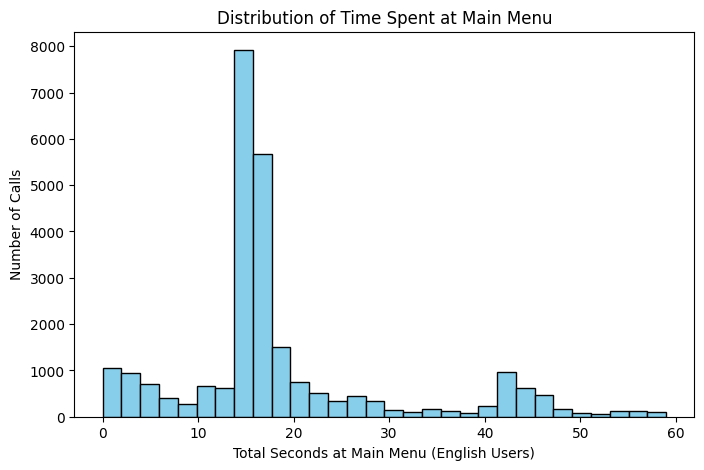

In [70]:
first_rows = df_english_transfer_trimmed.groupby("Contact Session ID").first().reset_index()
seconds = first_rows["seconds_until_next"]
seconds_filtered = seconds[seconds < 60] # 99% of calls end before the full prompt (removing outliers)

# --- Plot ---

plt.figure(figsize=(8,5))
plt.hist(seconds_filtered, bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Total Seconds at Main Menu (English Users)")
plt.ylabel("Number of Calls")
plt.title("Distribution of Time Spent at Main Menu")
plt.show()

In [71]:
seconds_filtered_df = seconds_filtered.to_frame(name="seconds_until_next")

# Export to CSV
seconds_filtered_df.to_csv("seconds_filtered_english.csv", index=False)

In [ ]:
total_count = len(seconds_filtered)

# 1) Percent of calls with a selection during first option
pct_6_14 = ((seconds_filtered >= 6) & (seconds_filtered <= 14)).sum() / total_count * 100

# 2) Percent of calls with a selection during second option
pct_36_40 = ((seconds_filtered >= 36) & (seconds_filtered <= 40)).sum() / total_count * 100

# 3) Percent of calls with a selection before hearing the second option
pct_le_35 = (seconds_filtered <= 35).sum() / total_count * 100

# Print results
print(f"Percentage between 6-14: {pct_6_14:.2f}%")
print(f"Percentage between 36-40: {pct_36_40:.2f}%")
print(f"Percentage <= 35: {pct_le_35:.2f}%")

Percentage between 6-14: 12.85%
Percentage between 36-40: 0.90%
Percentage <= 35: 87.77%


### Analysis 3: Time Distribution for Spanish Users

In [79]:
spanish_sessions = df_reached_beyond_main.loc[
    df_reached_beyond_main["Queue Name"] == "Staff Directory Spanish Transfer",
    "Contact Session ID"
].unique()

df_spanish_transfer = df_reached_beyond_main.loc[
    df_reached_beyond_main["Contact Session ID"].isin(spanish_sessions)
].copy()

result_rows = []

for session_id, group in df_spanish_transfer.groupby("Contact Session ID"):
    # Find **last MainMenu**
    mainmenu_idxs = group.index[group["Activity Name"] == "MainMenu"]
    start_idx = mainmenu_idxs[-1]
    
    # Find first Staff Directory English Transfer
    transfer_idxs = group.index[group["Activity Name"] == "StaffDirectorySpanishTransfer"]
    end_idx = transfer_idxs[0]
    
    # Slice from last MainMenu to first transfer
    result_rows.append(group.loc[start_idx:end_idx])

df_spanish_transfer_trimmed = pd.concat(result_rows, ignore_index=True)

df_spanish_transfer_trimmed = df_spanish_transfer_trimmed[
    df_spanish_transfer_trimmed["Activity Name"].notna()
].copy()


In [80]:
# Check the proportion of calls that enter the Staff Directory from somewhere other than MainMenu
call_sizes = df_spanish_transfer_trimmed.groupby("Contact Session ID").size()

num_calls_3plus = (call_sizes >= 3).sum()
total_calls = call_sizes.size

percentage_3plus = num_calls_3plus / total_calls * 100
print(f"Percentage of calls with 3+ rows: {percentage_3plus:.2f}%")

Percentage of calls with 3+ rows: 3.78%


In [81]:
# Count rows per call
call_sizes = df_spanish_transfer_trimmed.groupby("Contact Session ID").size()

# Get session IDs with exactly 2 rows
calls_2_rows = call_sizes[call_sizes == 2].index

# Filter the DataFrame to include only those calls
df_spanish_transfer_trimmed = df_spanish_transfer_trimmed[
    df_spanish_transfer_trimmed["Contact Session ID"].isin(calls_2_rows)
].copy()

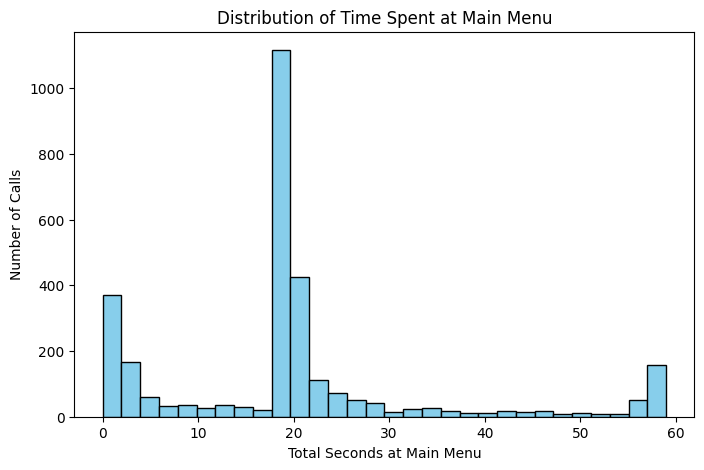

In [83]:
first_rows = df_spanish_transfer_trimmed.groupby("Contact Session ID").first().reset_index()
seconds = first_rows["seconds_until_next"]
seconds_filtered = seconds[seconds < 60] # 99% of calls end before the full prompt (removing outliers)

# --- Plot ---

plt.figure(figsize=(8,5))
plt.hist(seconds_filtered, bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Total Seconds at Main Menu")
plt.ylabel("Number of Calls")
plt.title("Distribution of Time Spent at Main Menu")
plt.show()

In [85]:
seconds_filtered_df = seconds_filtered.to_frame(name="seconds_until_next")

# Export to CSV
seconds_filtered_df.to_csv("seconds_filtered_spanish.csv", index=False)

In [ ]:
total_count = len(seconds_filtered)

# 1) Percent of calls with a selection during first option
pct_6_17 = ((seconds_filtered >= 6) & (seconds_filtered <= 17)).sum() / total_count * 100

# 2) Percent of calls with a selection during second option
pct_51_56 = ((seconds_filtered >= 51) & (seconds_filtered <= 56)).sum() / total_count * 100

# 3) Percent of calls with a selection before hearing the second option
pct_50 = (seconds_filtered <= 50).sum() / total_count * 100

# Print results
print(f"Percentage between 6-17: {pct_6_14:.2f}%")
print(f"Percentage between 51-56: {pct_51_56:.2f}%")
print(f"Percentage <= 50: {pct_50:.2f}%")

Percentage between 6-17: 12.85%
Percentage between 51-56: 0.80%
Percentage <= 50: 92.41%


### Analysis 4: Distribution of Next Activity from Key 8 of Main Menu

In [ ]:
# Get all Contact Session IDs that reach HelpWithLegalorOtherReasonMenu at least once
target_ids = (
    df_reached_beyond_main
    .loc[df_reached_beyond_main["Activity Name"] == "HelpWithLegalorOtherReasonMenu", 
         "Contact Session ID"]
    .unique()
)

# Create new df
df_reached_other = df_reached_beyond_main[
    df_reached_beyond_main["Contact Session ID"].isin(target_ids)
].copy()

In [ ]:
results = []

for session_id, group in df_reached_other.groupby("Contact Session ID"):
    # Find the FIRST instance of HelpWithLegalorOtherReasonMenu
    targets = group.index[group["Activity Name"] == "HelpWithLegalorOtherReasonMenu"]

    first_target_idx = targets[0]
    
    # Slice rows AFTER that instance
    after = group.loc[first_target_idx + 1 :]

    # Find the first non-NA activity name
    next_valid = after["Activity Name"].dropna().head(1)

    if len(next_valid) == 0:
        results.append("Abandoned")
    else:
        results.append(next_valid.iloc[0])

In [91]:
value_counts = pd.Series(results).value_counts()
value_counts

SeniorsMenu           4382
FrontDeskTransfer2    3642
MainMenu              3517
ClosedMenu             416
Abandoned               32
Name: count, dtype: int64

In [92]:
distribution = pd.Series(results).value_counts(normalize=True) * 100
distribution

SeniorsMenu           36.550171
FrontDeskTransfer2    30.377846
MainMenu              29.335224
ClosedMenu             3.469847
Abandoned              0.266911
Name: proportion, dtype: float64